<a href="https://colab.research.google.com/github/ravi-0309/Dynamic-Response/blob/main/Response_of_a_Truss_due_to_Ground_Motion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Enter coordinates for node 1 (x y z) in m: 0 1 0
Enter coordinates for node 2 (x y z) in m: 0 0.5 0.866
Enter coordinates for node 3 (x y z) in m: 0 0 0
Enter coordinates for node 4 (x y z) in m: 1 1 0
Enter coordinates for node 5 (x y z) in m: 1 0.5 0.866
Enter coordinates for node 6 (x y z) in m: 1 0 0
Enter coordinates for node 7 (x y z) in m: 2 1 0
Enter coordinates for node 8 (x y z) in m: 2 0.5 0.866
Enter coordinates for node 9 (x y z) in m: 2 0 0
Enter coordinates for node 10 (x y z) in m: 3 1 0
Enter coordinates for node 11 (x y z) in m: 3 0.5 0.866
Enter coordinates for node 12 (x y z) in m: 3 0 0
Enter coordinates for node 13 (x y z) in m: 4 1 0
Enter coordinates for node 14 (x y z) in m: 4 0.5 0.866
Enter coordinates for node 15 (x y z) in m: 4 0 0
Enter coordinates for node 16 (x y z) in m: 5 1 0
Enter coordinates for node 17 (x y z) in m: 5 0.5 0.866
Enter coordinates for node 18 (x y z) in m: 5 0 0
Enter the node numbers for element 1 (start end): 1 2
Enter the node numb

<ipython-input-6-d109f27d77d4>:151: RuntimeWarning: invalid value encountered in sqrt
  wn = np.sqrt(eigenvalues)  # Natural frequencies



Natural Frequencies (Hz):
[       nan        nan        nan        nan        nan        nan
 0.13440273 0.15253756 0.16541959 0.19195152 0.20536799 0.22285571
 0.22766279 0.24413147 0.25704611 0.26724476 0.27090188 0.29249018
 0.30662475 0.31790801 0.35072727 0.36265995 0.39250857 0.40095271
 0.41143081 0.44595822 0.45744176 0.49523271 0.49668035 0.55623054
 0.56342604 0.5866744  0.66773989]
                     
Modal Damping Ratios:
[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Eigenvalues:
[-1.66480660e-09 -1.37305921e-09 -1.14640442e-09 -1.00007715e-09
 -3.43167965e-17 -3.42644293e-17  1.80640946e-02  2.32677064e-02
  2.73636419e-02  3.68453851e-02  4.21760103e-02  4.96646657e-02
  5.18303454e-02  5.96001730e-02  6.60727004e-02  7.14197593e-02
  7.33878296e-02  8.5

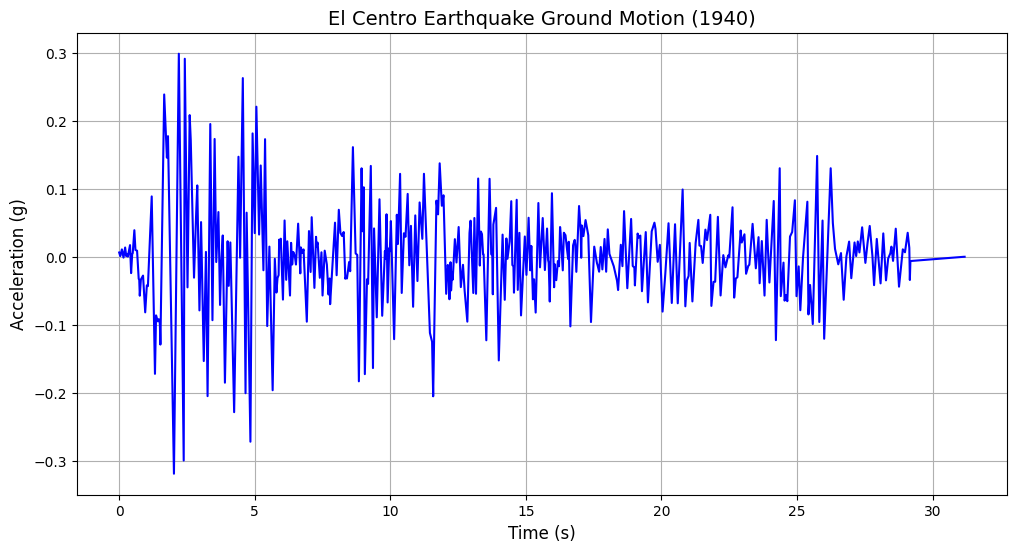

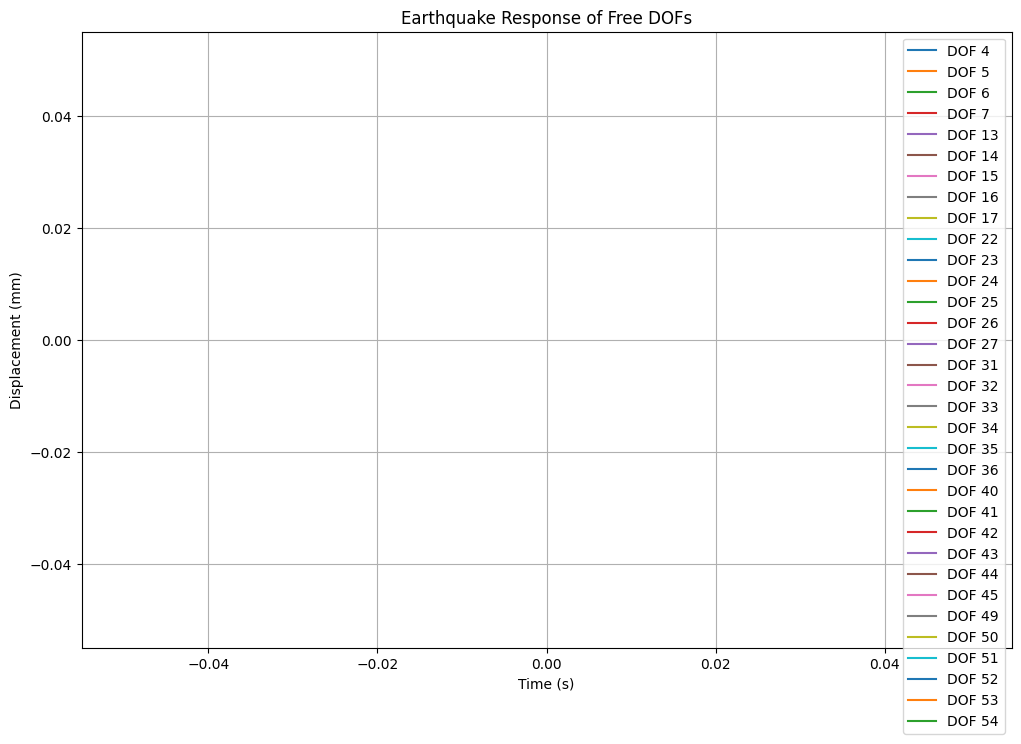


=== Enhanced Earthquake Response Animation ===

Maximum displacement: nan mm
Using scaling factor: 2500.00


ValueError: Axis limits cannot be NaN or Inf

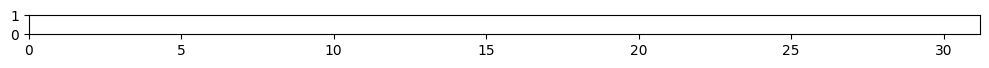

In [6]:
# MODE SHAPES AND RESPONSE OF A BRIDGE TRUSS DUE TO ELCENTRO GROUND MOTION

import numpy as np
import sympy as sp
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.animation import FuncAnimation
from scipy.linalg import eigh
from scipy.integrate import trapezoid
from IPython.display import HTML

# Geometric inputs
elements = 33 # number of members
nodes = 18 # number of nodes
constraints = 8 # number of supports
force = nodes - constraints # number of free nodes
A = 100.0 # Area (mm2)
E = 100000.0 # Modulus of Elasticity (MPa)

# Initialize arrays
node_coordinates = np.zeros((nodes, 3))  # 3D coordinates (x, y, z)
element_connectivity = np.zeros((elements, 2), dtype=int) # corresponding nodes for each element
constraints_x_y_z = np.zeros((constraints, 4)) # constraints of each nodes
element_orientation = np.zeros((elements, 3)) # direction cosines of each element
element_length = np.zeros(elements) # length of each elements
element_stiffness_matrices = [] # Initiating element's stiffness matrix
element_mass_matrices = [] # Initiating element's mass matrix
element_direction = np.zeros((elements, 6)) # numbering (x,y,z) directions for each node
global_stiffness_matrix = np.zeros((3*nodes, 3*nodes)) # global stiffness matrix
global_mass_matrix = np.zeros((3*nodes, 3*nodes)) # global mass matrix

# Loop to get coordinates for each node
for i in range(nodes):
  coord_input = input(f"Enter coordinates for node {i+1} (x y z) in m: ").split()
  x = float(coord_input[0]) * 1000.0 # in mm
  y = float(coord_input[1]) * 1000.0 # in mm
  z = float(coord_input[2]) * 1000.0 # in mm
  node_coordinates[i] = [x, y, z]

# Loop to get the node connectivity for each element
for i in range(elements):
  n1, n2 = map(int, input(f"Enter the node numbers for element {i+1} (start end): ").split())
  element_connectivity[i] = [n1, n2]

# Loop to get Constrained movements
for i in range(constraints):
  node, x, y, z = map(float, input(f"(n=node number, x,y,z=0 if no constraint, 1 if there is constraint (n x y z)): ").split())
  constraints_x_y_z[i] = [node, x, y, z]

# Loop to get element directions
dof = np.arange(1, 3*nodes+1)
directions = dof.reshape(-1, 3)
for i in range(elements):
  n1, n2 = element_connectivity[i]
  a, b, c = directions[n1-1]
  d, e, f = directions[n2-1]
  element_direction[i] = [a-1, b-1, c-1, d-1, e-1, f-1]

# Apply the constraints to the node_displacements matrix
node_displacements = np.zeros(3*nodes)
for i in range(constraints):
  node, x_constraint, y_constraint, z_constraint = constraints_x_y_z[i]
  if x_constraint == 1:
    node_displacements[3*int(node)-3] = 0
  if y_constraint == 1:
    node_displacements[3*int(node)-2] = 0
  if z_constraint == 1:
    node_displacements[3*int(node)-1] = 0

# Loop to calculate length, orientation and stiffness of each element
for i in range(elements):
  # Extracting Coordinates
  n1, n2 = element_connectivity[i]
  x1, y1, z1 = node_coordinates[n1-1]
  x2, y2, z2 = node_coordinates[n2-1]

  # Finding Length and Orientation
  L = round(np.sqrt((x2 - x1)**2 + (y2 - y1)**2 + (z2 - z1)**2), 2)
  cos_x = (x2-x1) / L
  cos_y = (y2-y1) / L
  cos_z = (z2-z1) / L
  element_length[i] = L
  element_orientation[i] = [cos_x, cos_y, cos_z]

  # Compute element stiffness matrix
  k = (E * A / L) * np.array([
      [cos_x**2    , cos_x*cos_y , cos_x*cos_z , -cos_x**2   , -cos_x*cos_y, -cos_x*cos_z],
      [cos_x*cos_y , cos_y**2    , cos_y*cos_z , -cos_x*cos_y, -cos_y**2   , -cos_y*cos_z],
      [cos_x*cos_z , cos_y*cos_z , cos_z**2    , -cos_x*cos_z, -cos_y*cos_z, -cos_z**2   ],
      [-cos_x**2   , -cos_x*cos_y, -cos_x*cos_z, cos_x**2    , cos_x*cos_y , cos_x*cos_z ],
      [-cos_x*cos_y, -cos_y**2   , -cos_y*cos_z, cos_x*cos_y , cos_y**2    , cos_y*cos_z ],
      [-cos_x*cos_z, -cos_y*cos_z, -cos_z**2   , cos_x*cos_z , cos_y*cos_z , cos_z**2    ]
    ])

  # Compute element mass matrix
  sigma = 100.0 # mass per unit length
  m = (sigma * L / 6.0) * np.array([
      [2.0, 0.0, 0.0, 1.0, 0.0, 0.0],
      [0.0, 2.0, 0.0, 0.0, 1.0, 0.0],
      [0.0, 0.0, 2.0, 0.0, 0.0, 1.0],
      [1.0, 0.0, 0.0, 2.0, 0.0, 0.0],
      [0.0, 1.0, 0.0, 0.0, 2.0, 0.0],
      [0.0, 0.0, 1.0, 0.0, 0.0, 2.0]
  ])

  # Store the stiffness matrix
  element_stiffness_matrices.append(k)
  element_mass_matrices.append(m)

# Generating Global Stiffness Matrix
for i in range(elements):
  indices = element_direction[i]
  for j in range(6):
    for k in range(6):
        global_stiffness_matrix[int(indices[j]), int(indices[k])] += round(element_stiffness_matrices[i][j, k], 3)
        global_mass_matrix[int(indices[j]), int(indices[k])] += round(element_mass_matrices[i][j, k], 3)

# Seggregating known and unknown dofs
constrained_dofs = []
free_dofs = []

# First identify all constrained DOFs
for i in range(constraints):
    node, x, y, z = constraints_x_y_z[i]
    node_idx = int(node) - 1  # convert to 0-based
    if x == 1: constrained_dofs.append(3*node_idx)
    if y == 1: constrained_dofs.append(3*node_idx + 1)
    if z == 1: constrained_dofs.append(3*node_idx + 2)

# Then free DOFs are all others
all_dofs = set(range(3*nodes))
free_dofs = sorted(list(all_dofs - set(constrained_dofs)))

# Calculating Degree of Static Indeterminacy
Ds = elements + len(constrained_dofs) - 3 * nodes
if Ds != 0:
  raise Exception("Degree of Static Indeterminacy is not zero")

# Ensure free_dofs isn't empty
if not free_dofs:
    raise ValueError("No free degrees of freedom! Check your constraints.")

# Extracting Sub Matrix for free DOFs of Stiffness and Mass
K = global_stiffness_matrix[free_dofs, :][:, free_dofs]
M = global_mass_matrix[free_dofs, :][:, free_dofs]

# Eigen Problem Solution
eigenvalues, phi = eigh(K, M)

wn = np.sqrt(eigenvalues)  # Natural frequencies
print("\nNatural Frequencies (Hz):")
print(wn)

# Modal Mass and Stiffness
Md = phi.T @ M @ phi
Kd = phi.T @ K @ phi

# Solve for modal damping
A = np.array([
    [1/(2*wn[1]), wn[1]/2],
    [1/(2*wn[2]), wn[2]/2]
])

xi_1 = 0.02
xi_2 = 0.02

xi_n = np.array([[xi_1], [xi_2]])
ab = np.linalg.inv(A) @ xi_n
C = ab[0] * M + ab[1] * K
Cd = phi.T @ C @ phi

# Modal Damping Ratio
eta_n = np.diag(Cd) / (2 * wn)
sp.pprint("\nModal Damping Ratios:")
print(eta_n)

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# File path in Google Drive
file_path = "/content/drive/My Drive/ELcentro_Accelaration_data.txt"

# Load data using pandas
df = pd.read_csv(file_path, delimiter="\t", header=None, names=["Time", "Acceleration"])

# Convert columns to arrays
time = df["Time"].values
xg_ddt = df["Acceleration"].values

# Earthquake excitation vector (assuming uniform excitation in all horizontal directions)
ifl = -1.0 * np.ones((len(free_dofs),1))  # Influence vector (all horizontal dofs)
F = M @ ifl  # Effective earthquake force
F_n = phi.T @ F  # Modal forces

def Duhamel_Integral(m, k, eta, t, f_t):
    """Computes the response using Duhamel's Integral via Trapezoidal Integration."""
    wn = np.sqrt(k / m)
    wd = wn * np.sqrt(1 - eta**2)
    nt = len(t)
    x_t = np.zeros(nt)

    for ii in range(1, nt):
        t_0 = t[0]
        t_st = t[ii]
        tau = t[:ii+1]
        f_tau = f_t[:ii+1]

        f1 = np.exp(eta * wn * tau) * np.cos(wd * tau) * f_tau
        f2 = np.exp(eta * wn * tau) * np.sin(wd * tau) * f_tau

        A_tau = trapezoid(f1, tau)
        B_tau = trapezoid(f2, tau)

        x_t[ii] = (1 / (m * wd)) * np.exp(-eta * wn * t_st) * (A_tau * np.sin(wd * t_st) - B_tau * np.cos(wd * t_st))

    return x_t

# Compute modal responses
num_modes = len(wn)
Z_n = np.zeros((num_modes, len(time)))

for i in range(num_modes):  # Loop over modes
    Z_n[i, :] = Duhamel_Integral(1, wn[i]**2, eta_n[i], time, F_n[i] * xg_ddt)

# Transform back to physical coordinates (relative displacement)
X_t = phi @ Z_n  # X_t is relative displacement of free DOFs

# Print the matrices
print("\nEigenvalues:")
sp.pprint(eigenvalues)
print("\nPhi:")
sp.pprint(phi)
print("\nGlobal Stiffness Matrix:")
sp.pprint(K)
print("\nGlobal Mass Matrix:")
sp.pprint(M)
print("\nModal Mass Matrix:")
sp.pprint(Md)
print("\nModal Stiffness Matrix:")
sp.pprint(Kd)
print("\nModal Damping Matrix:")
sp.pprint(Cd)
print("\nModal Damping Ratios:")
sp.pprint(eta_n)

# Set higher animation embed limit (in MB)
plt.rcParams['animation.embed_limit'] = 500  # Increase to 500MB

# Plot El Centro ground motion
plt.figure(figsize=(12, 6))
plt.plot(time, xg_ddt, 'b-', linewidth=1.5)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Acceleration (g)', fontsize=12)
plt.title('El Centro Earthquake Ground Motion (1940)', fontsize=14)
plt.grid(True)
plt.show()

# Plot the response of the first few DOFs
plt.figure(figsize=(12, 8))
for i in range(len(free_dofs)):
    plt.plot(time, X_t[i, :], label=f'DOF {free_dofs[i]+1}')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (mm)')
plt.title('Earthquake Response of Free DOFs')
plt.legend()
plt.grid(True)
plt.show()

# ANIMATE EARTHQUAKE RESPONSE
# =============================================

def animate_earthquake_response_enhanced():
    # Create figure with GridSpec layout
    fig = plt.figure(figsize=(18, 12))
    gs = gridspec.GridSpec(len(free_dofs), 2, width_ratios=[3, 1], wspace=0.2, hspace=0.5)

    # Calculate maximum displacement for scaling
    max_disp = np.max(np.abs(X_t))
    print(f"\nMaximum displacement: {max_disp:.4f} mm")

    # Automatic scaling factor
    structure_size = np.max(node_coordinates) - np.min(node_coordinates)
    scale = 0.5 * structure_size / (max_disp if max_disp > 0 else 1)
    print(f"Using scaling factor: {scale:.2f}")

    # Create displacement-time subplots for each DOF
    displacement_plots = []
    displacement_lines = []
    for i, dof in enumerate(free_dofs):
        ax = plt.subplot(gs[i, 0])
        ax.set_xlim(time[0], time[-1])
        ax.set_ylim(np.min(X_t[i])*1.1, np.max(X_t[i])*1.1)
        ax.set_xlabel('Time (s)', fontsize=10)
        ax.set_ylabel(f'DOF {dof+1} Disp (mm)', fontsize=10)
        ax.grid(True)
        line, = ax.plot([], [], 'b-', lw=2)
        displacement_plots.append(ax)
        displacement_lines.append(line)
        ax.set_title(f'Displacement Response for DOF {dof+1}')

    # Create 3D structure subplot
    ax_3d = plt.subplot(gs[:, 1], projection='3d')
    ax_3d.set_title("3D Structure Response", fontsize=12)

    # Initialize 3D structure lines
    original_lines = []
    deformed_lines = []
    for elem in element_connectivity:
        orig_line, = ax_3d.plot([], [], [], 'k-', alpha=0.3, linewidth=1)
        def_line, = ax_3d.plot([], [], [], 'r-', linewidth=3)
        original_lines.append(orig_line)
        deformed_lines.append(def_line)

    # Set 3D axis limits
    x_min, x_max = node_coordinates[:,0].min(), node_coordinates[:,0].max()
    y_min, y_max = node_coordinates[:,1].min(), node_coordinates[:,1].max()
    z_min, z_max = node_coordinates[:,2].min(), node_coordinates[:,2].max()

    padding = 0.3 * max(x_max-x_min, y_max-y_min, z_max-z_min)
    ax_3d.set_xlim(x_min-padding, x_max+padding)
    ax_3d.set_ylim(y_min-padding, y_max+padding)
    ax_3d.set_zlim(z_min-padding, z_max+padding)

    ax_3d.set_xlabel('X (mm)', fontsize=10)
    ax_3d.set_ylabel('Y (mm)', fontsize=10)
    ax_3d.set_zlabel('Z (mm)', fontsize=10)
    ax_3d.grid(True)
    ax_3d.view_init(elev=30, azim=45)

    # Create time text
    time_text = ax_3d.text2D(0.02, 0.95, '', transform=ax_3d.transAxes, fontsize=12)

    # Initialize function
    def init():
        # Initialize displacement plots
        for line in displacement_lines:
            line.set_data([], [])

        # Initialize 3D structure
        for i, elem in enumerate(element_connectivity):
            n1, n2 = elem
            x = [node_coordinates[n1-1,0], node_coordinates[n2-1,0]]
            y = [node_coordinates[n1-1,1], node_coordinates[n2-1,1]]
            z = [node_coordinates[n1-1,2], node_coordinates[n2-1,2]]
            original_lines[i].set_data(x, y)
            original_lines[i].set_3d_properties(z)
            deformed_lines[i].set_data(x, y)
            deformed_lines[i].set_3d_properties(z)

        time_text.set_text('Time: 0.00 s')
        return displacement_lines + original_lines + deformed_lines + [time_text]

    # Downsample time steps for smoother animation
    step = max(1, len(time) // 200)
    time_indices = np.arange(0, len(time), step)
    print(f"Animating {len(time_indices)} frames over {time[-1]:.2f} seconds")

    # Update function
    def update(frame):
        time_idx = time_indices[frame]
        current_time = time[time_idx]

        # Update displacement plots
        for i, line in enumerate(displacement_lines):
            line.set_data(time[:time_idx+1], X_t[i,:time_idx+1])

        # Update 3D structure
        displacement = np.zeros(3*nodes)
        displacement[free_dofs] = X_t[:, time_idx]

        for i, elem in enumerate(element_connectivity):
            n1, n2 = elem
            x1, y1, z1 = node_coordinates[n1-1]
            x2, y2, z2 = node_coordinates[n2-1]

            dx1 = scale * displacement[3*(n1-1)]
            dy1 = scale * displacement[3*(n1-1)+1]
            dz1 = scale * displacement[3*(n1-1)+2]

            dx2 = scale * displacement[3*(n2-1)]
            dy2 = scale * displacement[3*(n2-1)+1]
            dz2 = scale * displacement[3*(n2-1)+2]

            deformed_lines[i].set_data(
                [x1 + dx1, x2 + dx2],
                [y1 + dy1, y2 + dy2]
            )
            deformed_lines[i].set_3d_properties(
                [z1 + dz1, z2 + dz2]
            )

        time_text.set_text(f'Time: {current_time:.2f} s')
        return displacement_lines + deformed_lines + [time_text]

    # Create animation
    ani = FuncAnimation(
        fig, update, frames=len(time_indices), init_func=init,
        interval=50, blit=True, repeat=True
    )

    plt.close()
    print("\nRendering enhanced earthquake response animation...")
    display(HTML(ani.to_jshtml()))

# Execute enhanced earthquake response animation
print("\n=== Enhanced Earthquake Response Animation ===")
animate_earthquake_response_enhanced()

# MODE SHAPE VISUALIZATION AND ANIMATION
# =============================================

def animate_mode_shapes():
    num_modes = len(free_dofs)

    for mode in range(num_modes):
        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(111, projection='3d')
        ax.set_title(f"Mode {mode+1} - Frequency: {wn[mode]:.3f} Hz", fontsize=12)

        # Initialize lines
        original_lines = []
        deformed_lines = []
        for elem in element_connectivity:
            orig_line, = ax.plot([], [], [], 'k--', alpha=0.5, linewidth=1)
            def_line, = ax.plot([], [], [], 'r-', linewidth=3)
            original_lines.append(orig_line)
            deformed_lines.append(def_line)

        # Reconstruct full mode shape
        full_mode = np.zeros(3*nodes)
        full_mode[free_dofs] = phi[:,mode]

        # Calculate scaling factor automatically
        max_disp = np.max(np.abs(full_mode))
        scale = 0.2 * np.max(node_coordinates) / (max_disp if max_disp > 0 else 1)

        # Set axis limits
        all_coords = node_coordinates.flatten()
        coord_range = max(all_coords.max() - all_coords.min(), 1)
        padding = 0.2 * coord_range

        ax.set_xlim(node_coordinates[:,0].min()-padding, node_coordinates[:,0].max()+padding)
        ax.set_ylim(node_coordinates[:,1].min()-padding, node_coordinates[:,1].max()+padding)
        ax.set_zlim(node_coordinates[:,2].min()-padding, node_coordinates[:,2].max()+padding)

        ax.set_xlabel('X (mm)')
        ax.set_ylabel('Y (mm)')
        ax.set_zlabel('Z (mm)')

        def init():
            """Initialize the animation"""
            for i, elem in enumerate(element_connectivity):
                n1, n2 = elem
                # Original structure
                x = [node_coordinates[n1-1,0], node_coordinates[n2-1,0]]
                y = [node_coordinates[n1-1,1], node_coordinates[n2-1,1]]
                z = [node_coordinates[n1-1,2], node_coordinates[n2-1,2]]
                original_lines[i].set_data(x, y)
                original_lines[i].set_3d_properties(z)

                # Initial deformed position (same as original)
                deformed_lines[i].set_data(x, y)
                deformed_lines[i].set_3d_properties(z)

            return original_lines + deformed_lines

        def update(frame):
            time = frame / 10  # Slower animation
            displacement_factor = np.sin(2 * np.pi * time) * scale

            for i, elem in enumerate(element_connectivity):
                n1, n2 = elem

                # Original coordinates
                x1, y1, z1 = node_coordinates[n1-1]
                x2, y2, z2 = node_coordinates[n2-1]

                # Add scaled modal displacement
                dx1 = displacement_factor * full_mode[3*(n1-1)]
                dy1 = displacement_factor * full_mode[3*(n1-1)+1]
                dz1 = displacement_factor * full_mode[3*(n1-1)+2]

                dx2 = displacement_factor * full_mode[3*(n2-1)]
                dy2 = displacement_factor * full_mode[3*(n2-1)+1]
                dz2 = displacement_factor * full_mode[3*(n2-1)+2]

                # Update deformed lines
                deformed_lines[i].set_data(
                    [x1 + dx1, x2 + dx2],
                    [y1 + dy1, y2 + dy2]
                )
                deformed_lines[i].set_3d_properties(
                    [z1 + dz1, z2 + dz2]
                )

            return deformed_lines

        # Create animation
        ani = FuncAnimation(
            fig, update, frames=60, init_func=init,
            interval=50, blit=True, repeat=True
        )

        plt.close()
        print(f"\nMode {mode+1} Animation - Scaling Factor: {scale:.2f}")
        display(HTML(ani.to_jshtml()))

# Execute the animation
print("\n=== Mode Shape Animations ===")
animate_mode_shapes()
